In [ ]:
import pandas as pd 
import numpy as np 
import scipy

In [3]:
# p84

# 실습에 필요한 패키지들을 불러옵니다.
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt
from sklearn import datasets

In [5]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)

data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# 데이터를 DataFrame으로 구성 (컬럼 이름은 직접 설정해야 합니다)
X = pd.DataFrame(data, columns=['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'])
y = pd.DataFrame(target, columns=['MEDV'])

# 데이터세트를 학습 세트와 테스트 세트로 분할합니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

# K - 최근접 이웃 알고리즘


학습 세트 결정계수: 0.826
테스트 세트 결정계수: 0.808


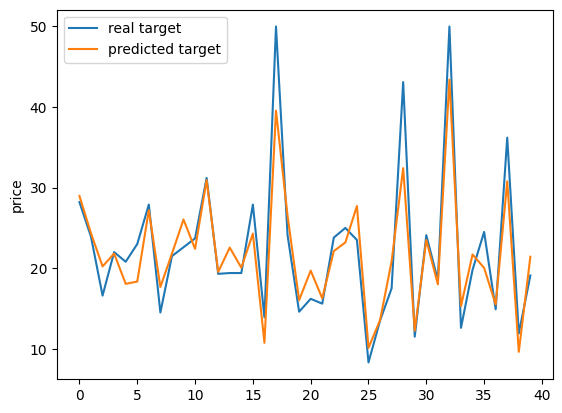

In [ ]:


# 데이터 범위 조정을 위해 표준화 객체를 생성합니다.
scaler = StandardScaler()

# 표준화 객체를 학습시킵니다.
scaler.fit(X_train)

# 학습 세트와 테스트 세트에 각각 표준화를 적용합니다.
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)

# K-최근접 이웃 모델 객체를 만듭니다.
model = KNeighborsRegressor(n_neighbors=5)

# K-최근접 이웃 모델에 학습 세트의 입력 데이터와 타깃을 넣고 학습시킵니다.
model.fit(X_train_std, y_train)

# 학습 세트에서의 결정계수와 테스트 세트에서의 결정계수를 계산합니다.
train_score = model.score(X_train_std, y_train)
test_score = model.score(X_test_std, y_test)

# 학습 세트에서의 결정계수와 테스트 세트에서의 결정계수를 출력합니다.
print('학습 세트 결정계수: {score:.3f}'.format(score=train_score))
print('테스트 세트 결정계수: {score:.3f}'.format(score=test_score))


# 학습된 모델에 테스트 세트의 입력 데이터를 다시 넣고 타깃을 추론합니다.
y_predicted = model.predict(X_test_std)

# 실제값과 추론값 사이의 관계를 꺾은선 그래프로 그립니다.
number_of_sample = 40
plt.plot(range(number_of_sample), y_test[:number_of_sample], label='real target')
plt.plot(range(number_of_sample), y_predicted[:number_of_sample], label='predicted target')
plt.ylabel('price')
plt.legend()
plt.show()

# 선형회귀 p94

학습 세트 R^2 점수: 0.717
테스트 세트 R^2 점수: 0.779


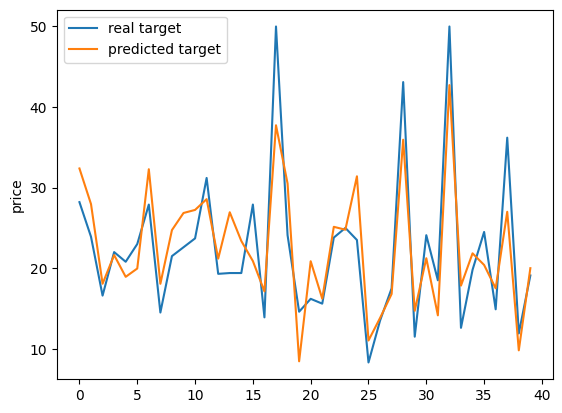

계수: [[-1.07145146  1.34036243  0.26298069  0.66554537 -2.49842551  1.97524314
   0.19516605 -3.14274974  2.66736136 -1.80685572 -2.13034748  0.56172933
  -4.03223518]]
y 절편: [22.34459103]


In [10]:
from sklearn.linear_model import LinearRegression

# 선형 회귀 모델 객체를 만듭니다.
model = LinearRegression()

# 선형 회귀 모델에 학습 세트의 입력 데이터와 타깃을 넣고 학습시킵니다.
model.fit(X_train_std, y_train)

# 학습 세트에서의 R^2 점수와 테스트 세트에서의 R^2 점수를 계산합니다.
train_score = model.score(X_train_std, y_train)
test_score = model.score(X_test_std, y_test)

# 학습 세트에서의 R^2 점수와 테스트 세트에서의 R^2 점수를 출력합니다.
print('학습 세트 R^2 점수: {score:.3f}'.format(score=train_score))
print('테스트 세트 R^2 점수: {score:.3f}'.format(score=test_score))


# 학습된 모델에 테스트 세트의 입력 데이터를 다시 넣고 타깃을 추론합니다.
y_predicted = model.predict(X_test_std)

# 실제값과 추론값 사이의 관계를 꺾은선 그래프로 그립니다.
number_of_sample = 40
plt.plot(range(number_of_sample), y_test[:number_of_sample], label='real target')
plt.plot(range(number_of_sample), y_predicted[:number_of_sample], label='predicted target')
plt.ylabel('price')
plt.legend()
plt.show()


# 학습된 계수(기울기)를 확인합니다.
print('계수: {coefficient}'.format(coefficient=model.coef_))

# 학습된 y 절편을 확인합니다.
print('y 절편: {y_intercept}'.format(y_intercept=model.intercept_))

In [11]:
# 2.1.3 로지스틱스 회귀 p 110


# 실습에 필요한 라이브러리를 불러옵니다.
from sklearn.linear_model import LogisticRegression
import numpy as np


# 시험 점수와 합격 여부 데이터를 준비합니다.
X = np.array([[35], [50], [60], [65], [70], [85], [95]])
y = np.array([0, 0, 0, 0, 1, 1, 1])


# 로지스틱 회귀 객체를 생성하고 모델을 학습시킵니다.
model = LogisticRegression()
model.fit(X, y)

# 학습된 모델을 이용해 타깃을 추론하고 결과를 확인합니다.
y_predicted = model.predict(X)
print(y_predicted)

# 테스트에 사용할 데이터를 준비합니다.
X_test = np.array([[45], [55], [75]])

# 테스트 데이터의 타깃을 추론하고 결과를 확인합니다.
y_test_predicted = model.predict(X_test)
print(y_test_predicted)

[0 0 0 0 1 1 1]
[0 0 1]


In [12]:
# 위스콘신 대학교 - 유방암 진단 실습 p116


# 실습에 필요한 라이브러리를 불러옵니다.
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


# 사이킷런에서 유방암 진단 데이터세트를 불러옵니다.
dataset = datasets.load_breast_cancer()

# 입력 데이터와 타깃을 준비합니다.
X, y = dataset['data'], dataset['target']

# 데이터세트를 학습 세트와 테스트 세트로 분할합니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)


# 데이터 범위 조정을 위해 표준화를 적용합니다.
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# 로지스틱 회귀 모델 객체를 만듭니다.
model = LogisticRegression()

# 로지스틱 회귀 모델에 학습 세트의 입력 데이터와 타깃을 넣고 학습시킵니다.
model.fit(X_train_std, y_train)

# 학습 세트에서의 정확도와 테스트 세트에서의 정확도를 계산합니다.
train_score = model.score(X_train_std, y_train)
test_score = model.score(X_test_std, y_test)

# 학습 세트에서의 정확도와 테스트 세트에서의 정확도를 출력합니다.
print('학습 세트 정확도: {:.3f}'.format(train_score))
print('테스트 세트 정확도: {:.3f}'.format(test_score))

학습 세트 정확도: 0.991
테스트 세트 정확도: 0.979


In [ ]:
# 2.1.4 서포트백터 머신 p120 ~ 124


# 실습에 필요한 라이브러리를 불러옵니다.
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC

# 사이킷런에서 붓꽃 품종 데이터세트를 가져옵니다.
dataset = datasets.load_iris()

# 입력 데이터와 타깃을 준비합니다.
X, y = dataset['data'], dataset['target']

# 데이터세트를 학습 세트와 테스트 세트로 분할합니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# 데이터 범위 조정을 위해 표준화를 적용합니다.
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)


# 선형 서포트 벡터 머신 모델 객체를 만듭니다.
model = LinearSVC(C=2.0)

# 선형 서포트 벡터 머신 모델에 학습 세트의 입력 데이터와 타깃을 넣고 학습시킵니다.
model.fit(X_train_std, y_train)


# 학습 세트에서의 정확도와 테스트 세트에서의 정확도를 계산합니다.
train_score = model.score(X_train_std, y_train)
test_score = model.score(X_test_std, y_test)

# 학습 세트에서의 정확도와 테스트 세트에서의 정확도를 출력합니다.
print('학습 세트 정확도: {:.3f}'.format(train_score))
print('테스트 세트 정확도: {:.3f}'.format(test_score))

학습 세트 정확도: 0.946
테스트 세트 정확도: 0.974
